# 1. Сигналы и преобразование Фурье

In [20]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 3.6),
                     'axes.grid': True, 'axes.unicode_minus': False})

## 1.1 Что такое сигнал
Изменение величины, несущее информацию

Звук: давление воздуха. Датчик: напряжение. Изображение: яркость

x(t) - значение в момент t

## 1.2 От измерений к массиву
Отсчет - отдельное измеренное значение

In [21]:
samples = np.array([0, 2, 0, -2], dtype=float)
print("Массив:", samples)
print("Первый отсчет:", samples[0])
print("Форма:", samples.shape, "Тип:", samples.dtype)

Массив: [ 0.  2.  0. -2.]
Первый отсчет: 0.0
Форма: (4,) Тип: float64


## 1.3 Время и частота дискретизации
fs - число измерений за секунду

In [22]:
fs = 8.0
n = np.arange(len(samples))
t = n / fs
print("Индексы:", n)
print("Время, с:", t)

Индексы: [0 1 2 3]
Время, с: [0.    0.125 0.25  0.375]


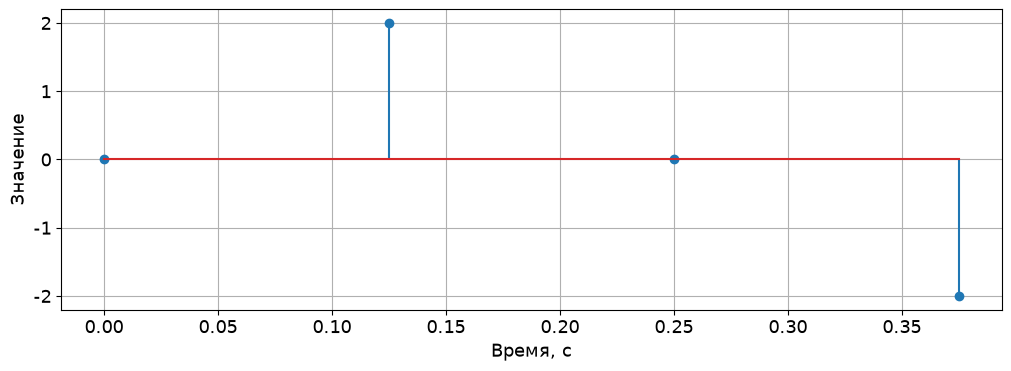

In [23]:
fig, ax = plt.subplots(layout="constrained")
ax.stem(t, samples)
ax.set(xlabel="Время, с", ylabel="Значение")
plt.show()

## 1.4 Простое колебание
A - амплитуда, f - частота, T=1/f - период, b - постоянный уровень

Частота: 2.0 Гц; период: 0.5 с


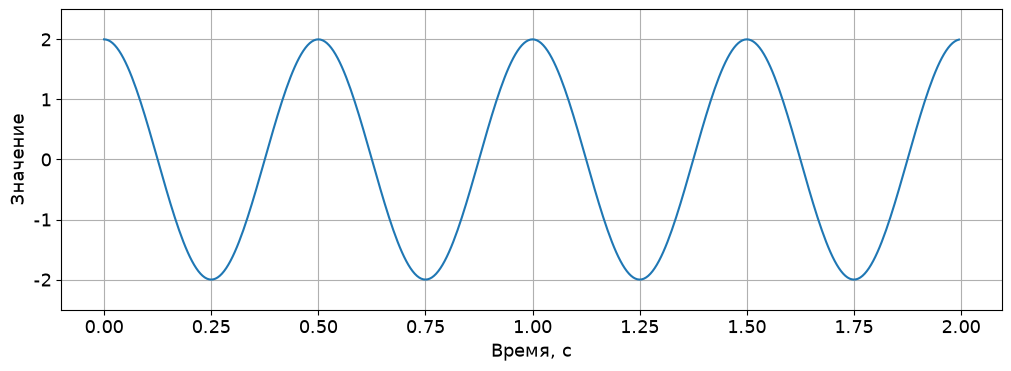

In [24]:
t_wave = np.arange(400)/200
A, f_wave, b = 2.0, 2.0, 0.0
wave = A*np.cos(2*np.pi*f_wave*t_wave)+b
print('Частота:', f_wave, 'Гц; период:', 1/f_wave, 'с')
fig, ax = plt.subplots(layout='constrained')
ax.plot(t_wave, wave)
ax.set(xlabel='Время, с', ylabel='Значение', ylim=(-2.5,2.5))
plt.show()

## 1.5 Фаза
Положение внутри периода. Полный цикл: 2*pi радиан

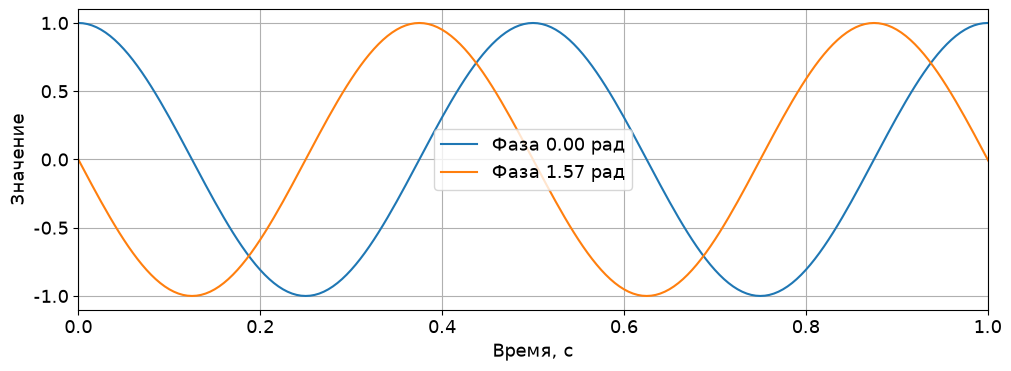

In [25]:
fig, ax = plt.subplots(layout='constrained')
for phi in (0, np.pi/2):
    ax.plot(t_wave, np.cos(2*np.pi*2*t_wave+phi), label=f'Фаза {phi:.2f} рад')
ax.set(xlabel='Время, с', ylabel='Значение', xlim=(0,1)); ax.legend()
plt.show()

In [ ]:
def wave_demo(A=1.0, f=2.0, phi=0.0):
    t = np.arange(400)/200
    fig, ax = plt.subplots(layout='constrained')
    ax.plot(t, A*np.cos(2*np.pi*f*t+phi))
    ax.set(xlabel='Время, с', ylabel='Значение', ylim=(-2.2,2.2))
    plt.show()
import ipywidgets as widgets
from IPython.display import display
display(widgets.interactive(wave_demo, A=(0.5,2.0,0.5), f=(1.0,5.0,1.0), phi=(-np.pi,np.pi,np.pi/4)))

interactive(children=(FloatSlider(value=1.0, description='A', max=2.0, min=0.5, step=0.5), FloatSlider(value=2…

## 1.6 Сложение сигналов
Сумма значений в одинаковые моменты времени

In [41]:
fs = 128.0
N = 128
t = np.arange(N)/fs
x1 = 2*np.cos(2*np.pi*5*t)
x2 = 0.7*np.cos(2*np.pi*12*t+np.pi/4)
x = 0.5+x1+x2
print('Первые значения суммы:', np.round(x[:8],3))

Первые значения суммы: [2.995 2.577 1.996 1.4   0.911 0.592 0.428 0.343]


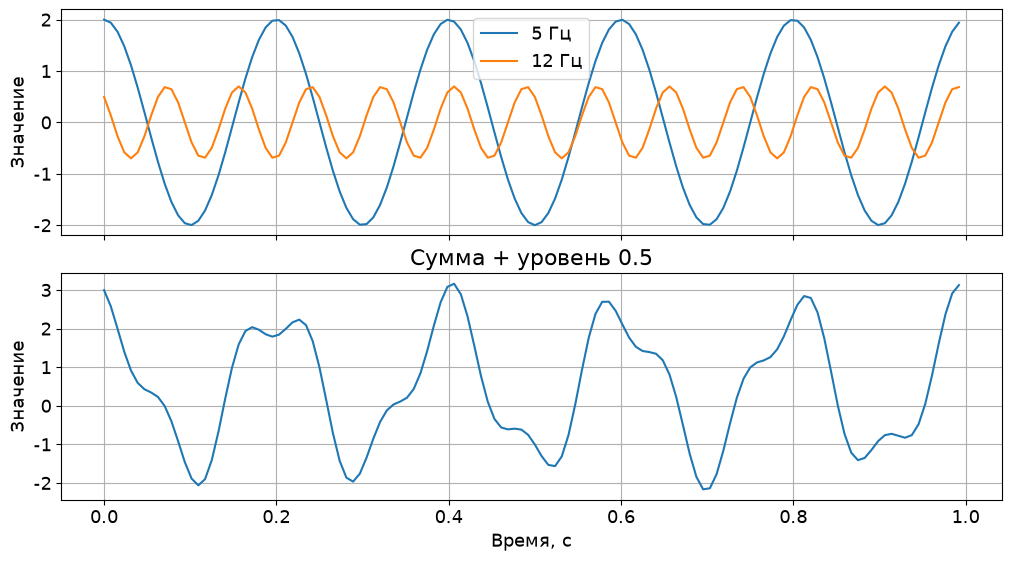

In [42]:
fig, axes = plt.subplots(2,1,figsize=(10,5.5),sharex=True,layout='constrained')
axes[0].plot(t,x1,label='5 Гц'); axes[0].plot(t,x2,label='12 Гц'); axes[0].legend()
axes[1].plot(t,x); axes[1].set(xlabel='Время, с',title='Сумма + уровень 0.5')
for ax in axes: ax.set_ylabel('Значение')
plt.show()

## 1.7 Сложная форма из синусоид
Приближение прямоугольного колебания

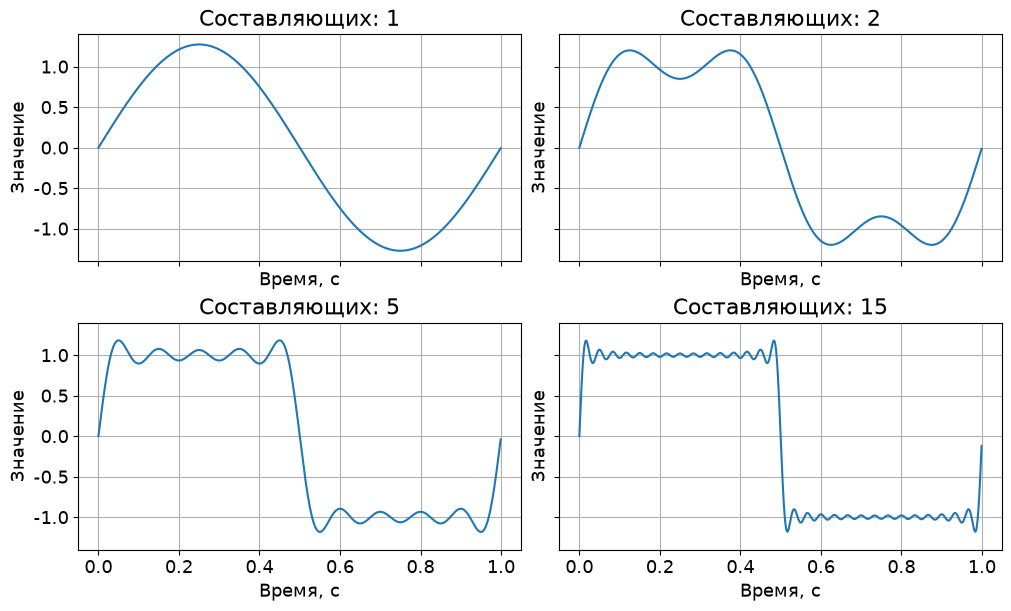

In [29]:
t_synthesis = np.linspace(0,1,1000,endpoint=False)
fig, axes = plt.subplots(2,2,figsize=(10,6),sharex=True,sharey=True,layout='constrained')
for ax, count in zip(axes.flat, [1,2,5,15]):
    approximation = np.zeros_like(t_synthesis)
    for k in range(1,2*count,2):
        approximation += 4/(np.pi*k)*np.sin(2*np.pi*k*t_synthesis)
    ax.plot(t_synthesis, approximation)
    ax.set(title=f'Составляющих: {count}', xlabel='Время, с', ylabel='Значение')
plt.show()

## 1.8 Обратная задача и преобразование Фурье
Известна сумма. Требуется определить составляющие

DFT - преобразование, FFT - быстрый алгоритм

In [30]:
X = np.fft.rfft(x)
freq = np.fft.rfftfreq(N,d=1/fs)
print("Форма результата:", X.shape)
print("Частоты:", freq[:14])
print("Коэффициент 12 Гц:", X[12])
print("Модуль:", abs(X[12]), "Угол:", np.angle(X[12]))

Форма результата: (65,)
Частоты: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]
Коэффициент 12 Гц: (31.678383797157423+31.678383797157238j)
Модуль: 44.800000000000004 Угол: 0.7853981633974454


## 1.9 Амплитудный спектр
Частота и амплитуда составляющей

In [65]:
amplitude = np.abs(X)/N
amplitude[1:-1] *= 2  # N четно; DC и Найквист не удваиваются
print("0, 5 и 12 Гц:", amplitude[[0,5,12]])

0, 5 и 12 Гц: [0.5 2.  0.7]


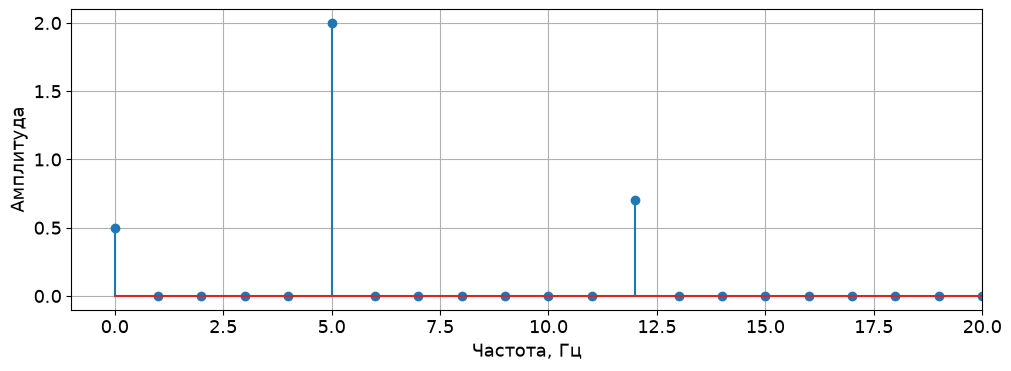

In [66]:
fig, ax = plt.subplots(layout="constrained")
ax.stem(freq,amplitude)
ax.set(xlabel="Частота, Гц",ylabel="Амплитуда",xlim=(-1,20))
plt.show()

## 1.10 Фазовый спектр и восстановление
Фаза отображается у заметных составляющих

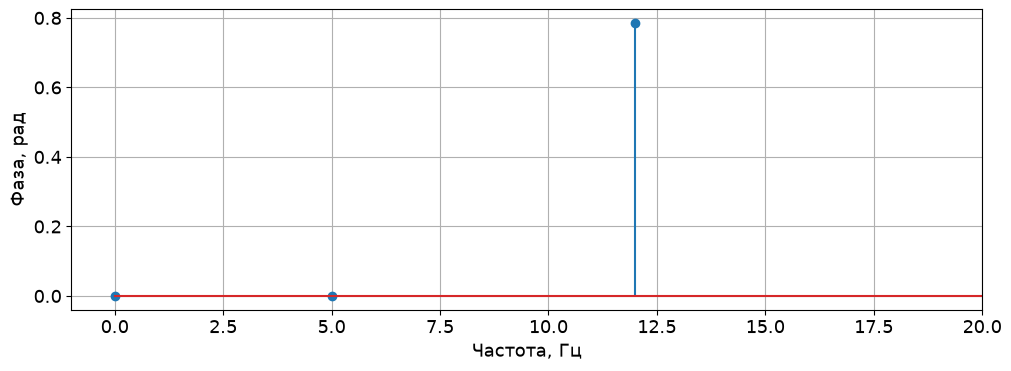

In [33]:
phase = np.where(amplitude > max(1e-12,amplitude.max()*1e-10),np.angle(X),np.nan)
fig, ax = plt.subplots(layout="constrained")
ax.stem(freq,phase)
ax.set(xlabel="Частота, Гц",ylabel="Фаза, рад",xlim=(-1,20))
plt.show()

In [34]:
restored = np.fft.irfft(X,n=N)
print("Максимальная ошибка:",np.max(np.abs(restored-x)))

Максимальная ошибка: 1.1102230246251565e-15


## 1.11 Повторение блока
Меняется длина записи и шаг частотной сетки

In [35]:
block = np.array([0,2,0,-2],dtype=float)
repeated = np.tile(block,5)
print("Блок:",block)
print("Повторение:",repeated)
print("Длина:",len(repeated))

Блок: [ 0.  2.  0. -2.]
Повторение: [ 0.  2.  0. -2.  0.  2.  0. -2.  0.  2.  0. -2.  0.  2.  0. -2.  0.  2.
  0. -2.]
Длина: 20


In [36]:
def spectrum(x, fs=1.0):
    x = np.asarray(x, dtype=float)
    N = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, d=1/fs)
    A = np.abs(X) / N
    if N % 2 == 0:
        A[1:-1] *= 2
    else:
        A[1:] *= 2
    phase = np.where(A > max(1e-12, A.max()*1e-10), np.angle(X), np.nan)
    return f, A, phase

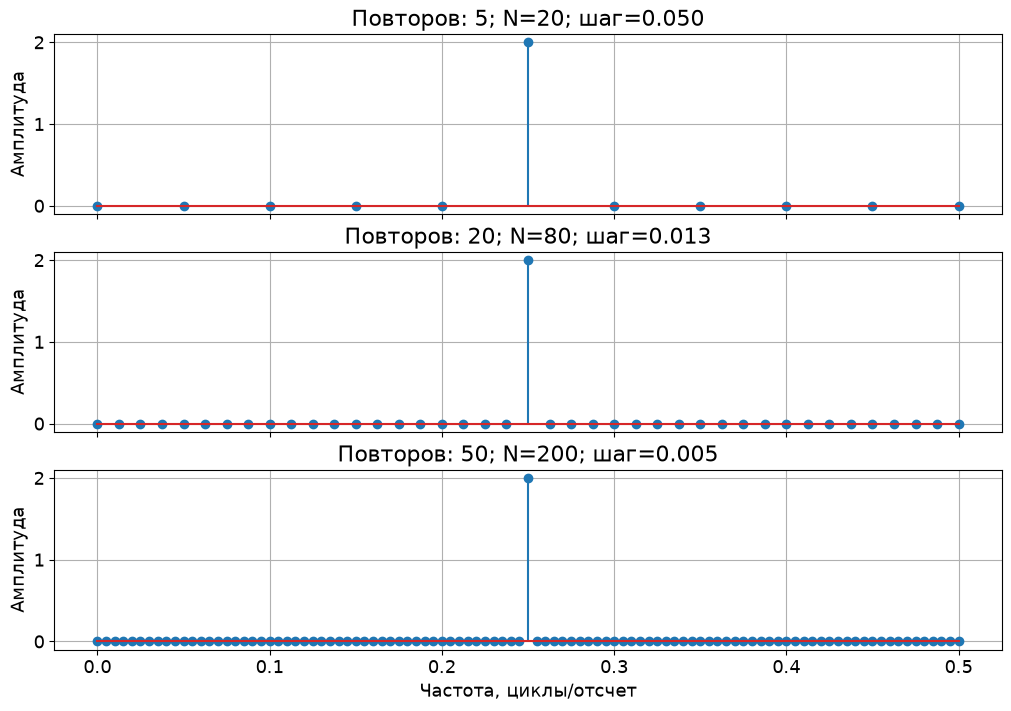

In [37]:
fig, axes = plt.subplots(3,1,figsize=(10,7),sharex=True,sharey=True,layout='constrained')
for ax,repeats in zip(axes,[5,20,50]):
    signal = np.tile(block,repeats)
    frequency, amp, _ = spectrum(signal,fs=1.0)
    ax.stem(frequency,amp)
    ax.set(title=f'Повторов: {repeats}; N={len(signal)}; шаг={1/len(signal):.3f}',ylabel='Амплитуда')
axes[-1].set_xlabel('Частота, циклы/отсчет')
plt.show()

## 1.12 Ограничение частоты дискретизации
2 и 6 Гц при fs=8 Гц дают одинаковые отсчеты

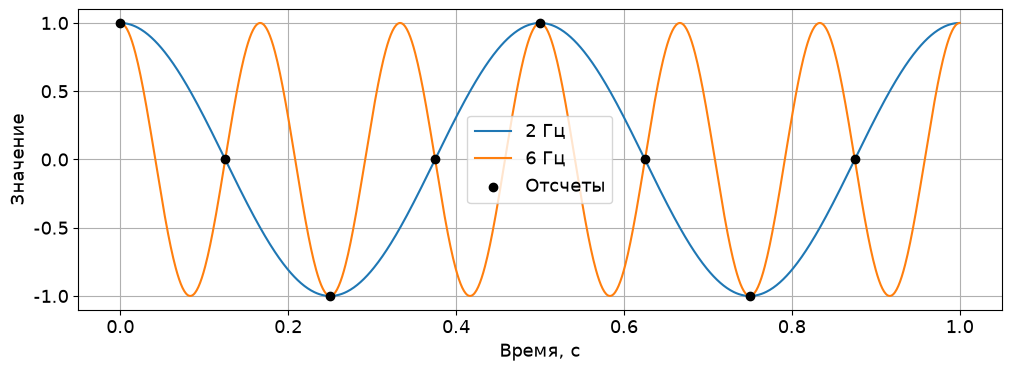

In [38]:
t_dense = np.linspace(0,1,1000)
t_samples = np.arange(8)/8
fig, ax = plt.subplots(layout='constrained')
for frequency in (2,6):
    ax.plot(t_dense,np.cos(2*np.pi*frequency*t_dense),label=f'{frequency} Гц')
ax.scatter(t_samples,np.cos(2*np.pi*2*t_samples),color='black',zorder=5,label='Отсчеты')
ax.set(xlabel='Время, с',ylabel='Значение'); ax.legend()
plt.show()

## Лабораторная работа
[Теория](THEORY.md) | [Задание](README.md) | [Шаблон](lab1.ipynb)